In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, recall_score, precision_recall_curve, average_precision_score, accuracy_score
from sklearn.svm import SVC
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.model_selection import GridSearchCV


In [2]:
# df_original = pd.read_csv('Children Recode_final.csv')
# df_original['Malnurished'] = df_original[['Underweight', 'Stunting', 'Wasting']].max(axis=1)
# df = df_original.drop(['Underweight', 'Stunting', 'Wasting'], axis = 1)
# df.head()

# X = df.drop(columns=['Malnurished'])
# y = df['Malnurished']

# # Train-test Split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state= 12)

# # Columns to scale
# columns_to_scale = ['Child_age', 'Age_first_sex', 'BMI', 'Mother_age_current', 'Mother_age_at_first_birth']
# scaler = StandardScaler()

# # Make copies of training and test sets
# X_train_scaled = X_train.copy()
# X_test_scaled = X_test.copy()

# # Scale only selected columns
# X_train_scaled[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
# X_test_scaled[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

# # Apply SMOTE
# sm = SMOTE(random_state=42)
# X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)

# print("Before SMOTE:", Counter(y_train))
# print("After SMOTE:", Counter(y_train_sm))

# # Train SVM with class weighting
# svm = SVC(
#     kernel='rbf',                
#     class_weight='balanced',     # adjusts weights for imbalance
#     probability=True,            
#     C=1.0,                       # regularization strength
#     gamma='scale'               # auto-tune kernel width
# )

# svm.fit(X_train_sm, y_train_sm)


# # Predict and evaluate
# y_pred = svm.predict(X_test_scaled)

# print("Classification Report on Test Set:")
# print(classification_report(y_test, y_pred))



In [3]:
# Load Data
df_original = pd.read_csv('df.csv')
df_original['Malnurished'] = df_original[['Underweight', 'Stunting', 'Wasting']].max(axis=1)
df = df_original.drop(['Underweight', 'Stunting', 'Wasting'], axis = 1)

# Train-test Split
X = df.drop(columns=['Malnurished'])
y = df['Malnurished']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, stratify = y, random_state = 42)

In [4]:
columns_to_scale = ['Child_age', 'BMI', 'Mother_age_current']
scaler = StandardScaler()

# X_train_scaled = X_train.copy()
# X_test_scaled = X_test.copy()

X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

In [5]:
svc = SVC(class_weight='balanced', probability=True)

# Define a grid for hyperparameter tuning
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Set up GridSearchCV using 'recall' as the scoring metric to focus on higher recall
grid_search = GridSearchCV(estimator=svc,
                           param_grid=param_grid,
                           scoring='recall',
                           cv=5,
                           n_jobs=-1,
                           verbose=2)

# Fit the grid search on the training data
grid_search.fit(X_train, y_train)

# Output the best parameters and best CV recall score found during tuning
print("Best Parameters:", grid_search.best_params_)
print("Best Recall Score (CV):", grid_search.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.8s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   1.3s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   1.3s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   1.1s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   1.1s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   1.9s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   1.7s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   1.8s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   1.6s
[CV] END ...................C=0.1, gamma=auto, kernel=linear; total time=   1.6s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   2.1s
[CV] END ...................C=0.1, gamma=auto, k

In [6]:
# Evaluate the best estimator on the test set
svc_best = grid_search.best_estimator_
y_pred = svc_best.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Test Accuracy: 0.5759637188208617
Test Recall: 0.6241610738255033
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.55      0.63       292
           1       0.42      0.62      0.50       149

    accuracy                           0.58       441
   macro avg       0.58      0.59      0.57       441
weighted avg       0.63      0.58      0.59       441



### Threshold Adjustment

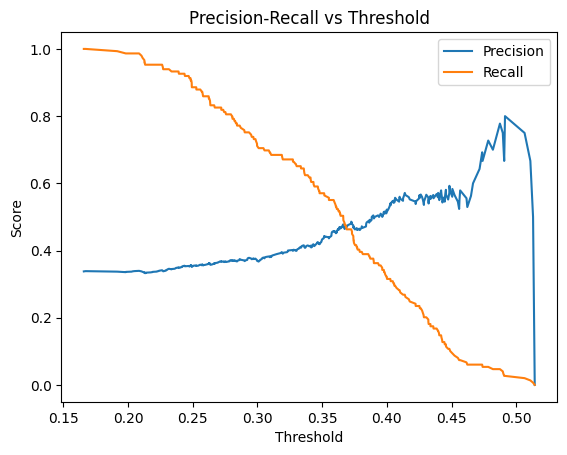

In [7]:
y_probas = svc_best.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.show()


In [8]:
y_probas = svc_best.predict_proba(X_test)[:, 1]  # Probabilities for class 1

# Apply custom threshold
y_probas_custom = (y_probas >= 0.40).astype(int)

print(f'Confusion Matrix: \n{pd.crosstab(y_test, y_probas_custom)}\n')
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Confusion Matrix: 
col_0          0   1
Malnurished         
0            248  44
1            102  47

Classification Report: 
              precision    recall  f1-score   support

           0       0.71      0.85      0.77       292
           1       0.52      0.32      0.39       149

    accuracy                           0.67       441
   macro avg       0.61      0.58      0.58       441
weighted avg       0.64      0.67      0.64       441




In [9]:
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')


Average Precision: 0.4685523691861611


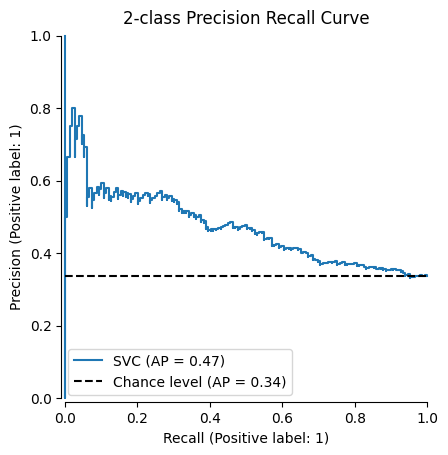

In [10]:
display = PrecisionRecallDisplay.from_estimator(
    svc_best,
    X_test,
    y_test, 
    name="SVC",
    plot_chance_level = True,
    despine = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()

### ROC-AUC Curve

In [11]:
y_probas_custom = svc_best.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_probas_custom)
auc = metrics.roc_auc_score(y_test, y_probas_custom)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

NameError: name 'metrics' is not defined